In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Incarcam setul de date
df=pd.read_csv("C:\\Users\\elian\\Desktop\\teme\\day.csv")

# Afisam primele 5 randuri din setul de date ca sa intelegem cu ce fel de date lucram
print("Primele 5 randuri din setul de date sunt:")
print(df.head())

# Afisam numarul de inregistrari si de coloane
print("Numarul de inregistrari si de coloane este:",df.shape)
#%%
# Verificam daca exista valori null
print("Valorile lipsa de pe fiecare coloana sunt:")
print(df.isnull().sum())

# A doua varianta pentru valori null ca sa fim 100% siguri
print("Exista valori lipsa in setul de date?:")
print(df.isnull().values.any())

Primele 5 randuri din setul de date sunt:
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  01-01-2018       1   0     1        0        6           0   
1        2  02-01-2018       1   0     1        0        0           0   
2        3  03-01-2018       1   0     1        0        1           1   
3        4  04-01-2018       1   0     1        0        2           1   
4        5  05-01-2018       1   0     1        0        3           1   

   weathersit       temp     atemp      hum  windspeed  casual  registered  \
0           2  14.110847  18.18125  80.5833  10.749882     331         654   
1           2  14.902598  17.68695  69.6087  16.652113     131         670   
2           1   8.050924   9.47025  43.7273  16.636703     120        1229   
3           1   8.200000  10.60610  59.0435  10.739832     108        1454   
4           1   9.305237  11.46350  43.6957  12.522300      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1

In [ ]:
# Selectam doar coloanele cu valori numerice relevante pentru a calcula media,mediana,deviatia standard si cvartiile acestora
cols_numerice = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

# Calculam media pentru valorile numerice
print("Media pentru valorile numerice este:")
print(df[cols_numerice].mean())

# Calculam mediana pentru valorile numerice
print("Mediana pentru valorile numerice este:")
print(df[cols_numerice].median())

# Calculam deviata standard pentru valorile numerice
print("Deviatia standard pentru valorile numerice este:")
print(df[cols_numerice].std())

# Calculam cvartiile pentru valorile numerice
print("Cvartiile pentru valorile numerice sunt:")
print(df[cols_numerice].quantile([0.25,0.5,0.75]))

# Adaugam media,mediana,deviatia standard si cvartiile intr-un singur tabel pentru o vizualizare mai buna
from IPython import display
print("Tabel cu media, mediana, deviata standard si cvartiile pentru valorile numerice:")
display.display(df[cols_numerice].describe().loc[['mean', '50%', 'std', '25%', '75%']])

Media pentru valorile numerice este:
temp            20.319259
atemp           23.726322
hum             62.765175
windspeed       12.763620
casual         849.249315
registered    3658.757534
cnt           4508.006849
dtype: float64
Mediana pentru valorile numerice este:
temp            20.465826
atemp           24.368225
hum             62.625000
windspeed       12.125325
casual         717.000000
registered    3664.500000
cnt           4548.500000
dtype: float64
Deviatia standard pentru valorile numerice este:
temp             7.506729
atemp            8.150308
hum             14.237589
windspeed        5.195841
casual         686.479875
registered    1559.758728
cnt           1936.011647
dtype: float64
Cvartiile pentru valorile numerice sunt:
           temp      atemp        hum  windspeed   casual  registered      cnt
0.25  13.811885  16.889713  52.000000   9.041650   316.25     2502.25  3169.75
0.50  20.465826  24.368225  62.625000  12.125325   717.00     3664.50  4548.50
0.75  

,temp,atemp,hum,windspeed,casual,registered,cnt
mean,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
50%,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
std,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
25%,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
75%,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000


In [ ]:
# Identificam variabilele categoriale
# Pasul 1: Vedem câte valori unice are fiecare coloană
print("Număr de valori unice per coloană:")
print(df.nunique())

# Pasul 2: Filtrăm coloanele care au mai puțin de 15 valori (acestea sunt categoriile)
categorii = [col for col in df.columns if df[col].nunique() < 15]

# Pasul 3: Afișăm variabilele categoriale identificate
print("Variabilele categoriale identificate sunt:")
print(categorii)

Număr de valori unice per coloană:
instant       730
dteday        730
season          4
yr              2
mnth           12
holiday         2
weekday         7
workingday      2
weathersit      3
temp          498
atemp         689
hum           594
windspeed     649
casual        605
registered    678
cnt           695
dtype: int64
Variabilele categoriale identificate sunt:
['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']


Media pe Sezoane (1:Iarna, 2:Primavara, 3:Vara, 4:Toamna):
season
1    2608.411111
2    4992.331522
3    5644.303191
4    4728.162921
Name: cnt, dtype: float64
Media pe Vreme (1:Limpede, 2:Nori/Ceață, 3:Ploaie/Zăpadă):
weathersit
1    4876.786177
2    4044.813008
3    1803.285714
Name: cnt, dtype: float64
Weekend/Sărbătoare (0) vs Media Zi Lucrătoare (1):
workingday
0    4330.168831
1    4590.332665
Name: cnt, dtype: float64


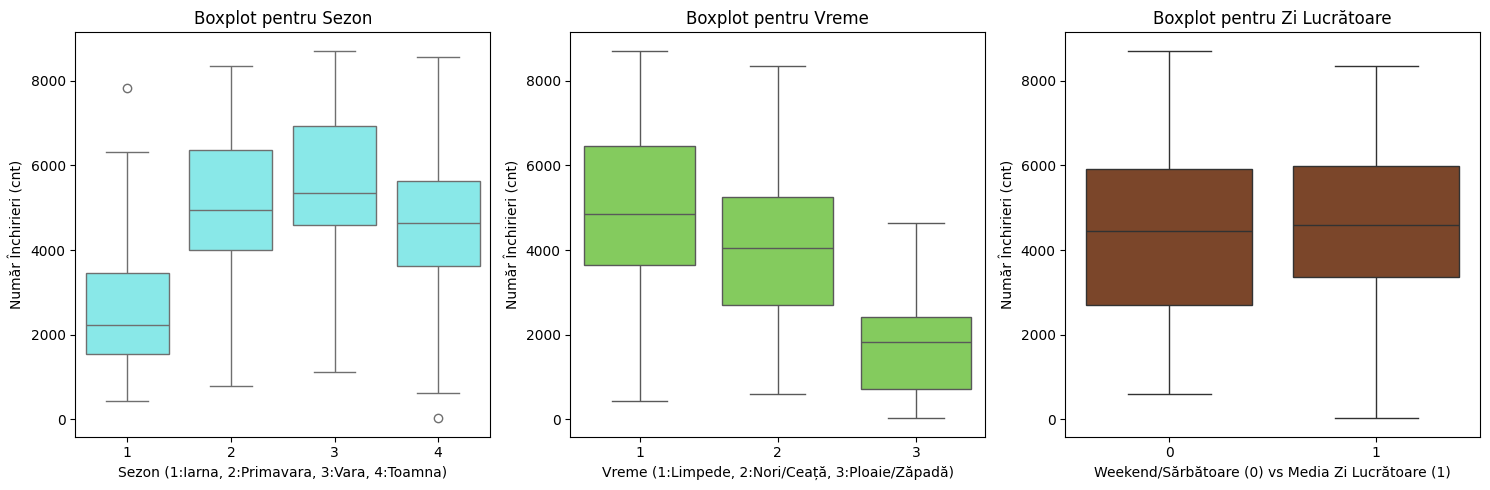

In [ ]:
# Calculăm media închirierilor (cnt) pentru diferite grupuri
medie_sezon = df.groupby('season')['cnt'].mean()
medie_vreme = df.groupby('weathersit')['cnt'].mean()
medie_lucru = df.groupby('workingday')['cnt'].mean()

print("Media pe Sezoane (1:Iarna, 2:Primavara, 3:Vara, 4:Toamna):")
print(medie_sezon)

print("Media pe Vreme (1:Limpede, 2:Nori/Ceață, 3:Ploaie/Zăpadă):")
print(medie_vreme)

print("Weekend/Sărbătoare (0) vs Media Zi Lucrătoare (1):")
print(medie_lucru)

# Realizam un boxplot cu 3 grafice pentru a intelege mai bine diferentele intre medii
plt.figure(figsize=(15, 5))

# Boxplot pentru Sezon
plt.subplot(1, 3, 1)
sns.boxplot(x='season', y='cnt', data=df, color='#79F8F8')
plt.title('Boxplot pentru Sezon')
plt.xlabel('Sezon (1:Iarna, 2:Primavara, 3:Vara, 4:Toamna)')
plt.ylabel('Număr Închirieri (cnt)')

# Boxplot pentru Vreme
plt.subplot(1, 3, 2)
sns.boxplot(x='weathersit', y='cnt', data=df, color='#7FDD4C')
plt.title('Boxplot pentru Vreme')
plt.xlabel('Vreme (1:Limpede, 2:Nori/Ceață, 3:Ploaie/Zăpadă)')
plt.ylabel('Număr Închirieri (cnt)')

# Boxplot pentru Zi Lucrătoare
plt.subplot(1, 3, 3)
sns.boxplot(x='workingday', y='cnt', data=df, color='#88421D')
plt.title('Boxplot pentru Zi Lucrătoare')
plt.xlabel('Weekend/Sărbătoare (0) vs Media Zi Lucrătoare (1)')
plt.ylabel('Număr Închirieri (cnt)')

# Afisare boxplot-urilor
plt.tight_layout()
plt.show()

In [ ]:
#Excludem coloanele care nu sunt variabile independente (instant, dteday, casual, registered)
# și calculăm corelația cu 'cnt'
corelatii_importante = df.drop(columns=['instant', 'dteday', 'casual', 'registered']).corr()['cnt'].sort_values(ascending=False)

print("Corelația variabilelor independente cu numărul de închirieri (cnt):")
print(corelatii_importante)

# Calculăm și diferența de medie pe ani pentru a susține importanța variabilei 'yr'
print("Media închirierilor pe ani (0=2018, 1=2019):")
print(df.groupby('yr')['cnt'].mean())

Corelația variabilelor independente cu numărul de închirieri (cnt):
cnt           1.000000
atemp         0.630685
temp          0.627044
yr            0.569728
season        0.404584
mnth          0.278191
weekday       0.067534
workingday    0.062542
holiday      -0.068764
hum          -0.098543
windspeed    -0.235132
weathersit   -0.295929
Name: cnt, dtype: float64
Media închirierilor pe ani (0=2018, 1=2019):
yr
0    3405.761644
1    5610.252055
Name: cnt, dtype: float64


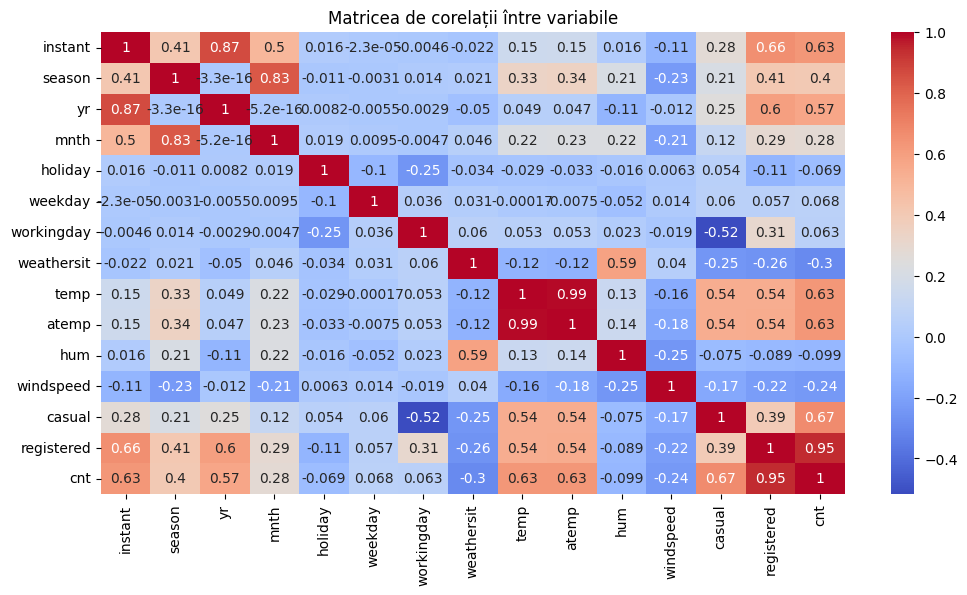

In [ ]:
# Selectăm doar coloanele numerice pentru corelație
df_numerice = df.select_dtypes(include=['int64', 'float64'])

# Calculam matricea de corelatie
corelatie = df_numerice.corr()

# Afișăm harta de corelații
plt.figure(figsize=(12,6))
sns.heatmap(corelatie, annot=True, cmap="coolwarm")
plt.title("Matricea de corelații între variabile")
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Selectăm variabile pentru exemplu (cele mai importante)
X = df[['temp', 'atemp', 'hum', 'windspeed']]

# Calculăm VIF pentru fiecare variabilă
# Dacă VIF > 10 → coliniaritate puternică
vif = pd.DataFrame()
vif["Variabila"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("VIF înainte de eliminare:")
print(vif)

# Temp si atemp au VIF mare, deci atemp poate fi eliminata din model.
# Eliminăm variabila atemp (are VIF foarte mare)
X = df[['temp', 'hum', 'windspeed']]

# Recalculăm VIF după eliminare
vif2 = pd.DataFrame()
vif2["Variabila"] = X.columns
vif2["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\nVIF după eliminarea variabilei 'atemp':")
print(vif2)

VIF înainte de eliminare:
   Variabila         VIF
0       temp  488.306256
1      atemp  542.888840
2        hum   11.071034
3  windspeed    4.678072

VIF după eliminarea variabilei 'atemp':
   Variabila       VIF
0       temp  7.132959
1        hum  9.052993
2  windspeed  4.677354


In [ ]:
# Creăm o copie a dataframe-ului original
df_dummies = df.copy()

# Eliminăm coloanele care nu sunt necesare pentru model
df_dummies = df_dummies.drop(columns=['instant', 'dteday', 'casual', 'registered', 'atemp'])
df_dummies = pd.get_dummies(df_dummies, columns=['season', 'weathersit', 'mnth'], drop_first=True)

#  Convertim tot tabelul la tip numeric 
df_dummies = df_dummies.astype(float)

# Verificam noul set de date
print("Verificare tipuri de date (trebuie să fie toate float):")
print(df_dummies.dtypes.head())

Verificare tipuri de date (trebuie să fie toate float):
yr            float64
holiday       float64
weekday       float64
workingday    float64
temp          float64
dtype: object


In [ ]:
# Efectuam Regresia Liniară 
import statsmodels.api as sm

df_model = df_dummies # Acum df_model este definit corect

X_clean = df_model.drop(columns=['cnt'])
y_clean = df_model['cnt']

# Adăugăm constanta
X_clean = sm.add_constant(X_clean)
model = sm.OLS(y_clean, X_clean).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     171.7
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          7.32e-271
Time:                        09:59:45   Log-Likelihood:                -5871.9
No. Observations:                 730   AIC:                         1.179e+04
Df Residuals:                     706   BIC:                         1.190e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1533.6024    233.171      6.577   

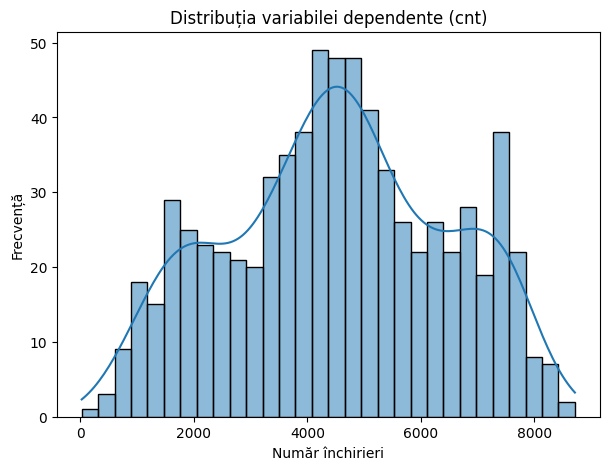

In [ ]:
# Verifica distribuția variabilei dependente 'cnt'
plt.figure(figsize=(7,5))
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title("Distribuția variabilei dependente (cnt)")
plt.xlabel("Număr închirieri")
plt.ylabel("Frecvență")
plt.show()

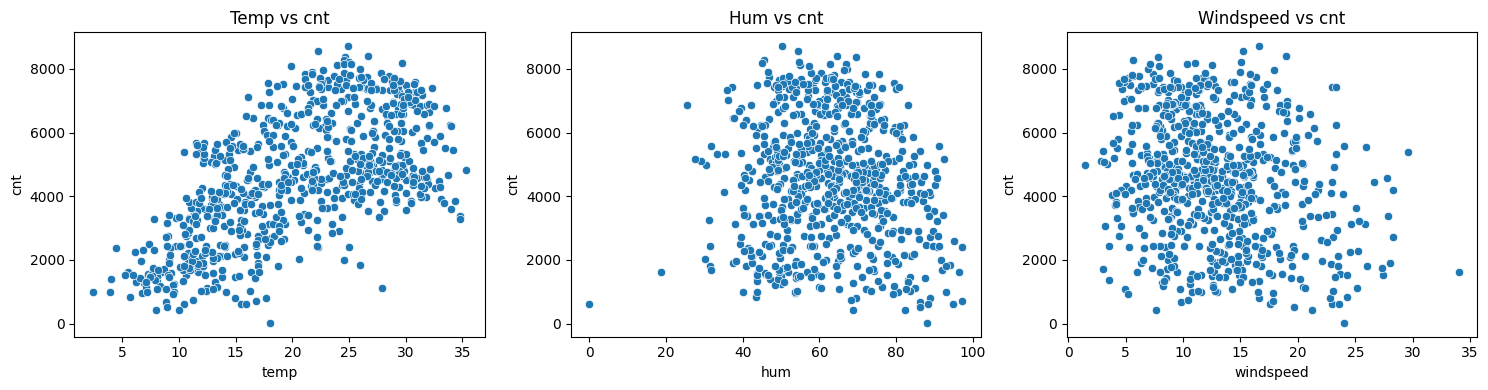

In [ ]:
# Scatterplot pentru variabilele importante din regresie
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temp vs cnt")

plt.subplot(1,3,2)
sns.scatterplot(x='hum', y='cnt', data=df)
plt.title("Hum vs cnt")

plt.subplot(1,3,3)
sns.scatterplot(x='windspeed', y='cnt', data=df)
plt.title("Windspeed vs cnt")

plt.tight_layout()
plt.show()

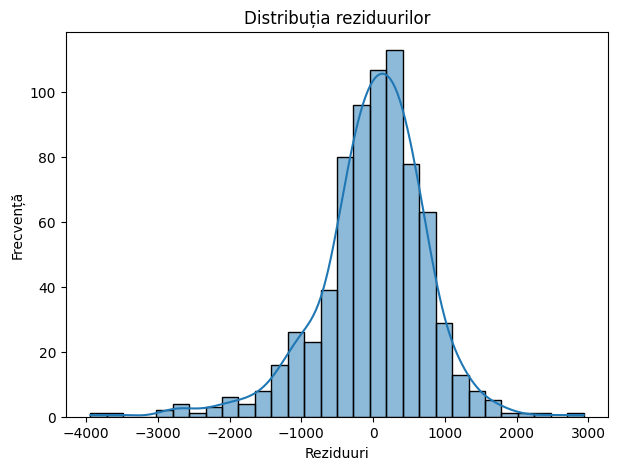

In [ ]:
# Verificăm reziduurile modelului
residuurile = model.resid
plt.figure(figsize=(7,5))
sns.histplot(residuurile, bins=30, kde=True)
plt.title("Distribuția reziduurilor")
plt.xlabel("Reziduuri")
plt.ylabel("Frecvență")
plt.show()

In [ ]:
# Intrebari si raspunsuri specifice setului nostru de date 
# Întrebarea 1: Care este luna cu cel mai mare număr mediu de închirieri?
top_luna = df.groupby('mnth')['cnt'].mean().idxmax()
valoare_luna = df.groupby('mnth')['cnt'].mean().max()
print(f"1. Luna cu cele mai multe închirieri medii: Luna {top_luna} (Media: {valoare_luna:.0f})")

# Întrebarea 2: Cât de mult scade cererea în zilele cu vreme nefavorabilă (3) față de cele cu vreme bună (1)?
vreme_buna = df[df['weathersit'] == 1]['cnt'].mean()
vreme_rea = df[df['weathersit'] == 3]['cnt'].mean()
scadere_procent = ((vreme_buna - vreme_rea) / vreme_buna) * 100
print(f"2. Scăderea cererii în zilele cu vreme rea: {scadere_procent:.2f}%")

# Întrebarea 3: Cine închiriază mai mult în weekend: utilizatorii ocazionali (casual) sau cei înregistrați (registered)?
weekend_data = df[df['workingday'] == 0]
media_casual = weekend_data['casual'].mean()
media_registered = weekend_data['registered'].mean()
print(f"3. În weekend, media utilizatorilor: Casual ({media_casual:.0f}) vs Registered ({media_registered:.0f})")

# Întrebarea 4: Care a fost ziua record (maximă) din întregul set de date?
zi_record = df.loc[df['cnt'].idxmax()]
print(f"4. Recordul absolut de închirieri: {zi_record['cnt']} unități în data {zi_record['dteday']}")

# Întrebarea 5: Cum a crescut segmentul de utilizatori 'Casual' față de 'Registered' între cei doi ani?
crestere_utilizatori = df.groupby('yr')[['casual', 'registered']].mean()
print("5. Media utilizatorilor pe ani (2018 vs 2019):")
print(crestere_utilizatori)

# Întrebarea 6: Care este impactul vântului puternic asupra numărului de închirieri?
# Considerăm vânt puternic peste 18 mph și vânt slab sub 10 mph
vant_puternic = df[df['windspeed'] > 18]['cnt'].mean()
vant_slab = df[df['windspeed'] < 10]['cnt'].mean()
print(f"6. Media închirierilor: Vânt puternic (>18): {vant_puternic:.0f} vs Vânt slab (<10): {vant_slab:.0f}")

1. Luna cu cele mai multe închirieri medii: Luna 6 (Media: 5772)
2. Scăderea cererii în zilele cu vreme rea: 63.02%
3. În weekend, media utilizatorilor: Casual (1371) vs Registered (2959)
4. Recordul absolut de închirieri: 8714 unități în data 15-09-2019
5. Media utilizatorilor pe ani (2018 vs 2019):
        casual   registered
yr                         
0    677.40274  2728.358904
1   1021.09589  4589.156164
6. Media închirierilor: Vânt puternic (>18): 3781 vs Vânt slab (<10): 4917
